In [ ]:
## For Figure 6 in benchmarking paper -- BIONTE census data
## Make a three panel figure showing observed and simulated growth rates, 
## disturbance recovery, and mortality rates

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
#
## this next library contains some helper functions for reshaping FATES variables into easier to work with dimensions
import ctsm_py
import ctsm_py.fates_xarray_funcs as fa       
#

In [49]:
path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/BIONTE_census/'
file='BIONTE_2023v1_gapfilled_wd.csv'
df = pd.read_csv(path+file)

/tmp/ipykernel_387185/2577915757.py:3: DtypeWarning: Columns (7,8,190,197,198) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path+file)


In [50]:
df = df.replace(-1111.0, np.nan)    # -1111 means individual did not exist yet or too small
df = df.replace(-3333.0, np.nan)    # -3333 individual died
df = df.replace(-9999.0, np.nan)    # -9999 missing data, reason unknown

In [51]:
df.shape

(15355, 199)

In [5]:
ntrees=15355

In [88]:
### total ground area for each treatment

total_area=100.*100.*3.# m2 --  Gilberto: 3 ha per treatment

In [52]:
# T0: control with no logging; 
# T1: light logging, with 33% of commercially viable biomass removed; 
# T2: medium logging, with 50% of commercially viable biomass removed; 
# T3: heavy logging, with 66% of commercially viable biomass removed. 

treatment=df['treatment'].values

In [53]:
growthfile='BIONTE_2023v1_growth_per-species-avg.csv'
# observed growth rates -- verify that this is in units of cm/yr

In [54]:
df_growth = pd.read_csv(path+growthfile)

In [57]:
df_growth

,Species,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,UNKNOWN,0.068923,0.100068,0.106935,0.095092,0.103467,0.119486,0.097019,0.122529,0.121116,...,0.125980,0.079368,0.037036,0.111991,0.115671,0.118187,0.078794,0.134848,0.081258,0.136213
1,abarema.adenophora,0.030000,0.600000,0.500000,0.300000,0.450000,0.450000,0.400000,0.200000,0.400000,...,0.600000,0.200000,0.500000,0.200000,-0.400000,1.700000,0.600000,0.900000,0.000000,1.700000
2,abarema.cf.microcalyx,0.830000,0.900000,0.800000,0.400000,0.900000,0.200000,0.800000,0.100000,0.100000,...,0.200000,0.600000,0.900000,0.600000,1.800000,1.300000,0.700000,0.700000,0.800000,0.700000
3,abarema.cochleata,0.000000,0.050000,-0.050000,0.075000,-0.050000,0.050000,0.025000,0.000000,-0.012500,...,0.100000,0.075000,-0.050000,0.150000,0.175000,0.100000,-0.075000,0.300000,-0.125000,0.175000
4,abarema.jupunba,0.026000,0.160000,0.120000,0.080000,0.290000,0.090000,0.020000,0.040000,0.070000,...,0.280000,0.180000,0.120000,0.380000,0.100000,0.100000,0.180000,0.080000,0.200000,0.240000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,xylopia.crinita,0.800000,0.600000,0.600000,-0.730000,-0.725000,-0.730000,-0.730000,-0.730000,-0.725000,...,0.100000,0.050000,0.000000,0.050000,0.050000,0.000000,0.000000,0.000000,0.100000,0.000000
780,xylopia.nitida,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.350000,...,0.680000,0.640000,0.260000,0.580000,0.560000,0.440000,0.460000,0.500000,0.420000,0.520000
781,xylopia.polyantha,0.177368,0.147368,0.221053,0.115789,0.115789,0.157895,0.163158,0.089474,0.110526,...,0.252632,0.263158,0.147368,0.210526,0.131579,0.200000,0.100000,0.136842,0.105263,0.121053
782,zygia.racemosa,0.130000,0.227778,0.323611,0.165278,0.161111,0.190278,0.127778,0.154167,0.056250,...,0.109722,0.073611,0.091667,0.236111,0.113889,0.134722,0.088889,0.172222,0.134722,0.168056


In [55]:
# Average yearly mortality rates, per species
# verify that this is in units of fraction plants per year
mortfile='BIONTE_2023v1_mortality_per-species-avg.csv'

In [56]:
df_mort = pd.read_csv(path+mortfile)

In [58]:
df_mort

,Species,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,UNKNOWN,0.008014,0.012987,0.007316,0.197616,0.020387,0.01703,0.011628,0.013046,0.013396,...,0.010304,0.016712,0.015795,0.017647,0.007172,0.014071,0.009005,0.012862,0.016874,0.019564
1,abarema.adenophora,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,abarema.cf.microcalyx,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,abarema.cochleata,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,abarema.jupunba,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,xylopia.crinita,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
780,xylopia.nitida,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,...,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
781,xylopia.polyantha,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.055556,0.062500,...,0.000000,0.071429,0.076923,0.000000,0.000000,0.000000,0.000000,0.000000,0.083333,0.000000
782,zygia.racemosa,0.025000,0.023810,0.000000,0.011364,0.034884,0.00000,0.022727,0.000000,0.000000,...,0.020000,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000


In [64]:
# growth dataset has DBH by year for 1990 - 2023

years= np.arange(1990,2024,1)
growth_by_year= np.zeros((len(years),784))

for i in range(len(years)):
    growth_by_year[i,:]=df_growth[str(years[i])].values

In [65]:
# mortality dataset has DBH by year for 1991 - 2023

years= np.arange(1991,2024,1)
mort_by_year= np.zeros((len(years),784))

for i in range(len(years)):
    mort_by_year[i,:]=df_mort[str(years[i])].values

In [66]:
all_t0_ind=np.where(treatment =='T0')
all_t1_ind=np.where(treatment =='T1')
all_t2_ind=np.where(treatment =='T2')
all_t3_ind=np.where(treatment =='T3')

In [67]:
# dataset has DBH by year for 1980 - 2023
years= np.arange(1980,2024,1)
dbh_by_year= np.zeros((len(years),ntrees))

for i in range(len(years)):
    dbh_by_year[i,:]=df[str(years[i])].values

In [68]:
ba_by_year=3.14159*(0.5*dbh_by_year)**2

In [86]:
## calculate BA vs year by treatment
### Logging occurred in 1986
years= np.arange(1980,2024,1)
nyears=len(years)

census_age_struc0=np.zeros(nyears)
blah0=np.where(treatment == 'T0') 
census_age_struc1=np.zeros(nyears)
blah1=np.where(treatment == 'T1') 
census_age_struc2=np.zeros(nyears)
blah2=np.where(treatment == 'T2') 
census_age_struc3=np.zeros(nyears)
blah3=np.where(treatment == 'T3') 

for i in range(nyears):
    census_age_struc0[i]=np.nansum(ba_by_year[i,blah0[0]])
    census_age_struc1[i]=np.nansum(ba_by_year[i,blah1[0]])
    census_age_struc2[i]=np.nansum(ba_by_year[i,blah2[0]])
    census_age_struc3[i]=np.nansum(ba_by_year[i,blah3[0]])



In [69]:
## Read in FATES file

fates_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/SummaryFiles/'
tag='hydro_comp_bmort_kmax_tune_sapflow_kmax3_5xHR_fixSLA_vcmax40.55_fixHR_branch'
file=tag+'.elm.h0.cat.nc'
d0 = xr.open_dataset(fates_path+file)


In [70]:
# BIONTE
bionte_lat=-2.638
bionte_lon=360.-60.154725
lat_abs_diff = np.abs(d0.lat.data - bionte_lat)
bionte_lat_ind = np.argmin(lat_abs_diff)
lon_abs_diff = np.abs(d0.lon.data - bionte_lon)
bionte_lon_ind = np.argmin(lon_abs_diff)


In [ ]:
# FATES mortality rates are in number of plants per m2 per year
# divide by nplants (number of plants per m2) to get 
# mortality rate in fraction per year

In [72]:
canopy_mort=fa.scpf_to_scls_by_pft(d0.FATES_MORTALITY_CANOPY_SZPF,d0)
nplant_canopy=fa.scpf_to_scls_by_pft(d0.FATES_NPLANT_CANOPY_SZPF,d0)

In [73]:
ustory_mort=fa.scpf_to_scls_by_pft(d0.FATES_MORTALITY_USTORY_SZPF,d0)
nplant_ustory=fa.scpf_to_scls_by_pft(d0.FATES_NPLANT_USTORY_SZPF,d0)


In [74]:
# only include plants above 10 cm DBH to be consistent with census data
canopy_mort_rate_early=canopy_mort.isel(fates_levpft=0).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))/nplant_canopy.isel(fates_levpft=0).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))
ustory_mort_rate_early=ustory_mort.isel(fates_levpft=0).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))/nplant_ustory.isel(fates_levpft=0).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))

canopy_mort_rate_late=canopy_mort.isel(fates_levpft=1).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))/nplant_canopy.isel(fates_levpft=1).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))
ustory_mort_rate_late=ustory_mort.isel(fates_levpft=1).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))/nplant_ustory.isel(fates_levpft=1).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))


In [75]:
## will use to filter on plant number density
early_can_filt=nplant_canopy.isel(fates_levpft=0).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))
early_ust_filt=nplant_ustory.isel(fates_levpft=0).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))

late_can_filt=nplant_canopy.isel(fates_levpft=1).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))
late_ust_filt=nplant_ustory.isel(fates_levpft=1).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))

In [ ]:
# FATES growth rates

In [76]:
# m m-2 yr-1
canopy_growth=fa.scpf_to_scls_by_pft(d0.FATES_DDBH_CANOPY_SZPF,d0)
nplant_canopy=fa.scpf_to_scls_by_pft(d0.FATES_NPLANT_CANOPY_SZPF,d0)

In [77]:
# m m-2 yr-1
ustory_growth=fa.scpf_to_scls_by_pft(d0.FATES_DDBH_USTORY_SZPF,d0)
nplant_ustory=fa.scpf_to_scls_by_pft(d0.FATES_NPLANT_USTORY_SZPF,d0)


In [78]:
# only include plants above 10 cm DBH to be consistent with census data
# convert from m/m2/yr to cm/m2/yr
canopy_growth_rate_early=100.*canopy_growth.isel(fates_levpft=0).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))/nplant_canopy.isel(fates_levpft=0).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))
ustory_growth_rate_early=100.*ustory_growth.isel(fates_levpft=0).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))/nplant_ustory.isel(fates_levpft=0).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))

canopy_growth_rate_late=100.*canopy_growth.isel(fates_levpft=1).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))/nplant_canopy.isel(fates_levpft=1).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))
ustory_growth_rate_late=100.*ustory_growth.isel(fates_levpft=1).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))/nplant_ustory.isel(fates_levpft=1).isel(fates_levscls=slice(2,14)).isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2))


In [79]:
ba_unrolled=fa.scpf_to_scls_by_pft(d0.FATES_BASALAREA_SZPF,d0)

In [80]:
nplants_unrolled=fa.scpf_to_scls_by_pft(d0.FATES_NPLANT_SZPF,d0)

In [81]:

def _get_check_dim(dim_short, dataset):
    """Get dim name from short code and ensure it's on Dataset

    Probably only useful internally to this module; see deduplex().

    Args:
        dim_short (string): The short name of the dimension. E.g., "age"
        dataset (xarray Dataset): The Dataset we expect to include the dimension

    Raises:
        NameError: Dimension not found on Dataset

    Returns:
        string: The long name of the dimension. E.g., "fates_levage"
    """

    dim = "fates_lev" + dim_short
    if dim not in dataset.dims:
        raise NameError(f"Dimension {dim} not present in Dataset with dims {dataset.dims}")
    return dim


def _get_dim_combined(dim1_short, dim2_short):
    """Get duplexed dimension name, given two short names

    Args:
        dim1_short (string): Short name of first duplexed dimension. E.g., when de-duplexing
                             fates_levscpf, dim1_short=scls.
        dim2_short (string): Short name of second duplexed dimension. E.g., when de-duplexing
                             fates_levscpf, dim2_short=pft.

    Returns:
        string: Duplexed dimension name
    """
    dim_combined = "fates_lev" + dim1_short + dim2_short

    # Handle further-shortened dim names
    if dim_combined == "fates_levcanleaf":
        dim_combined = "fates_levcnlf"
    elif dim_combined == "fates_levcanpft":
        dim_combined = "fates_levcapf"
    elif dim_combined == "fates_levcdamscls":
        dim_combined = "fates_levcdsc"
    elif dim_combined == "fates_levsclsage":
        dim_combined = "fates_levscag"
    elif dim_combined == "fates_levsclspft":
        dim_combined = "fates_levscpf"

    return dim_combined


def deduplex(dataset, this_var, dim1_short, dim2_short, preserve_order=True):
    """Reshape a duplexed FATES dimension into its constituent dimensions

    For example, given a variable with dimensions
        (time, fates_levagepft, lat, lon),
    this will return a DataArray with dimensions
        (time, fates_levage, fates_levpft, lat, lon)
    Or with reorder=False:
        (time, fates_levpft, lat, lon, fates_levage).

    Args:
        dataset (xarray Dataset): Dataset containing the variable with dimension to de-duplex
        this_var (string or xarray DataArray): (Name of) variable with dimension to de-duplex
        dim1_short (string): Short name of first duplexed dimension. E.g., when de-duplexing
                             fates_levagepft, dim1_short=age.
        dim2_short (string): Short name of second duplexed dimension. E.g., when de-duplexing
                             fates_levagepft, dim2_short=pft.
        preserve_order (bool, optional): Preserve order of dimensions of input DataArray? Defaults
                                         to True. Might be faster if False. See examples above.

    Raises:
        RuntimeError: dim1_short == dim2_short (not yet handled)
        TypeError: Incorrect type of this_var
        NameError: Dimension not found on Dataset

    Returns:
        xarray DataArray: De-duplexed variable
    """

    if dim1_short == dim2_short:
        raise RuntimeError("deduplex() can't currently handle dim1_short==dim2_short")

    # Get DataArray
    if isinstance(this_var, xr.DataArray):
        da_in = this_var
    elif isinstance(this_var, str):
        da_in = dataset[this_var]
    else:
        raise TypeError("this_var must be either string or DataArray, not " + type(this_var))

    # Get combined dim name
    dim_combined = _get_dim_combined(dim1_short, dim2_short)
    if dim_combined not in da_in.dims:
        raise NameError(f"Dimension {dim_combined} not present in DataArray with dims {da_in.dims}")

    # Get individual dim names
    dim1 = _get_check_dim(dim1_short, dataset)
    dim2 = _get_check_dim(dim2_short, dataset)

    # Split multiplexed dimension into its components
    n_dim1 = len(dataset[dim1])
    da_out = (
        da_in.rolling({dim_combined: n_dim1}, center=False)
        .construct(dim1)
        .isel({dim_combined: slice(n_dim1 - 1, None, n_dim1)})
        .rename({dim_combined: dim2})
        .assign_coords({dim1: dataset[dim1]})
        .assign_coords({dim2: dataset[dim2]})
    )

    # Reorder so that the split dimensions are together and in the expected order
    if preserve_order:
        new_dim_order = []
        for dim in da_out.dims:
            if dim == dim2:
                new_dim_order.append(dim1)
            if dim != dim1:
                new_dim_order.append(dim)
        da_out = da_out.transpose(*new_dim_order)

    return da_out


In [82]:
def appf_to_age_by_pft(appf_var, dataset):
    """function to reshape a fates multiplexed size and pft-indexed variable to one indexed by size class and pft
    first argument should be an xarray DataArray that has the FATES SCPF dimension
    second argument should be an xarray Dataset that has the FATES SCLS dimension
    (possibly the dataset encompassing the dataarray being transformed)
    returns an Xarray DataArray with the size and pft dimensions disentangled"""
    return deduplex(dataset, appf_var, "age", "pft", preserve_order=False)


In [83]:
ba_appf_unrolled=appf_to_age_by_pft(d0.FATES_BA_APPF, d0)

In [85]:
fates_initial_ba_tot=((100**2)*ba_appf_unrolled).mean(dim="time").sum(dim="fates_levpft").isel(lat=slice(bionte_lat_ind-1,bionte_lat_ind+2)).isel(lon=slice(bionte_lon_ind-1,bionte_lon_ind+2)).mean(dim='lat').mean(dim='lon').isel(fates_levage=0)

In [ ]:
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['figure.autolayout'] = False
plt.rcParams['font.size'] = 10
##plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300


/tmp/ipykernel_387185/406226135.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


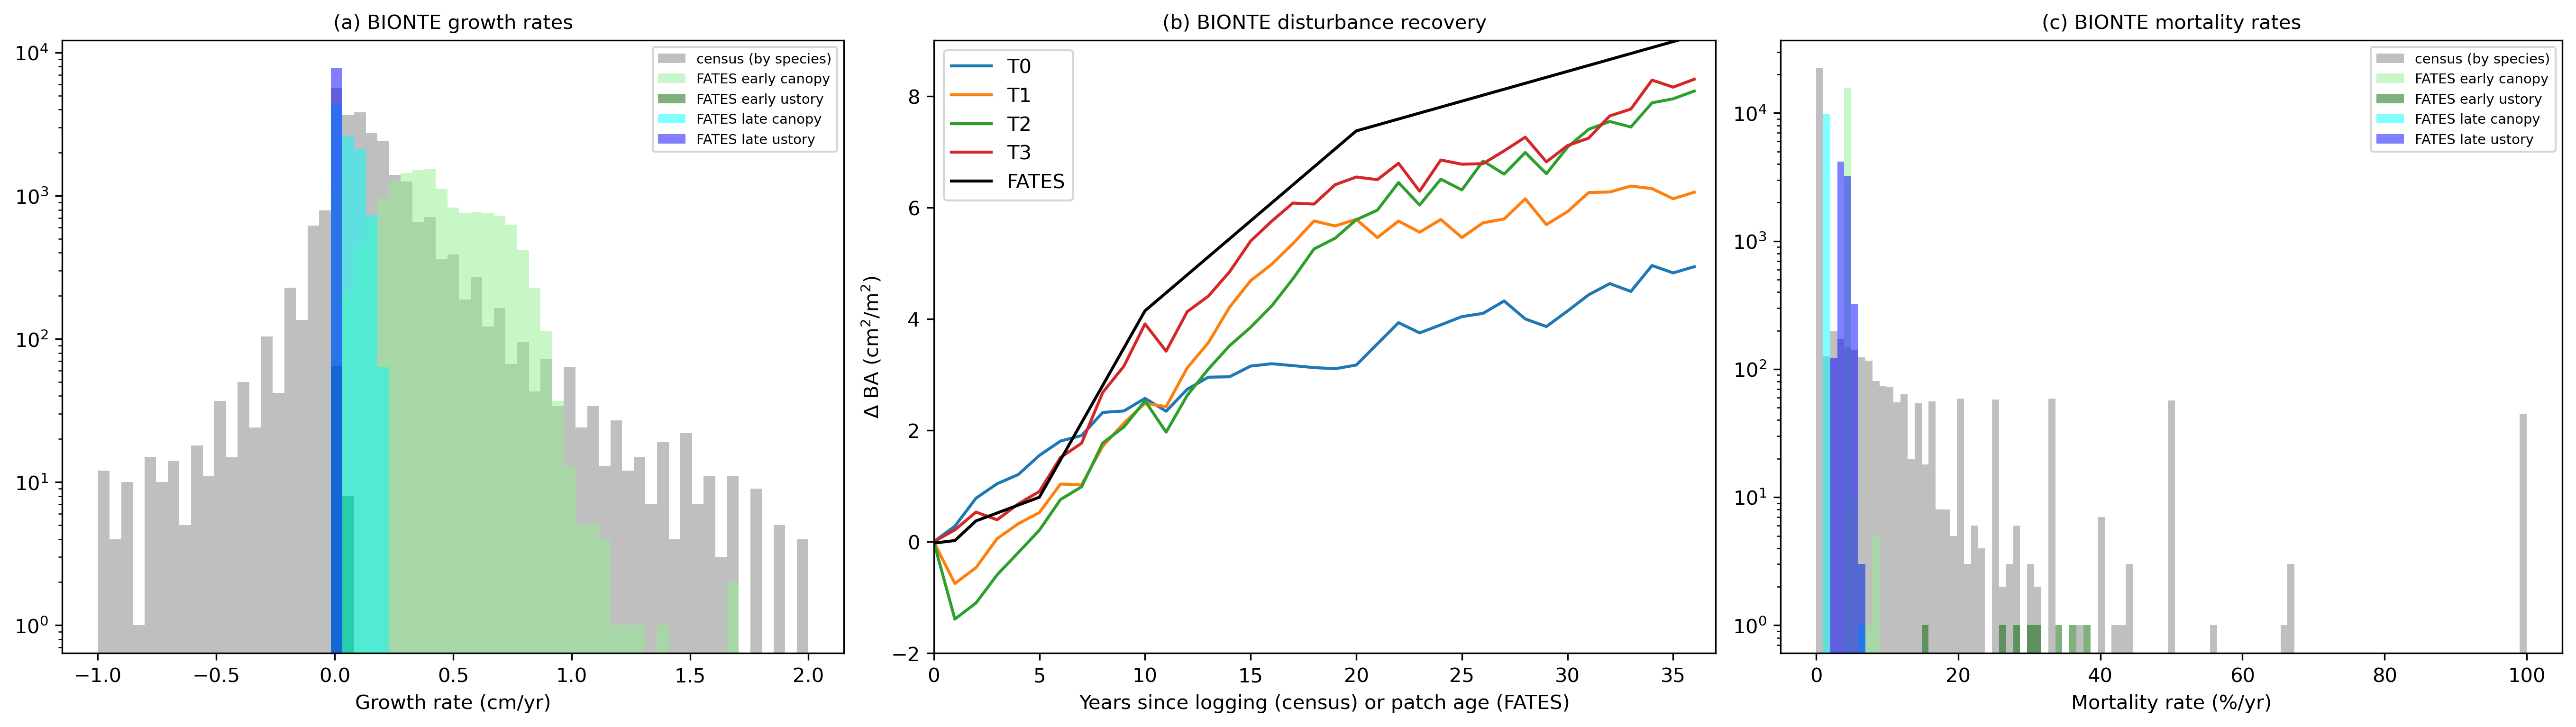

In [118]:
# Make three-panel figure

# only plot simulation results above certain plant density
filt=1./10000. #  plant per ha

# 1. Initialize a 1 row x 3 columns figure layout
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

# ==========================================
# PANEL A: Growth rates (ax1)
# ==========================================
ax1.hist(growth_by_year.flatten(), log=True, range=(-1,2), bins=61, label="census (by species)", color="grey", alpha=0.5)
ax1.hist(canopy_growth_rate_early.where(early_can_filt > filt).values.flatten(), log=True, range=(-1,2), bins=61, label="FATES early canopy", color="lightgreen", alpha=0.5)
ax1.hist(ustory_growth_rate_early.where(early_ust_filt > filt).values.flatten(), log=True, range=(-1,2), bins=61, label="FATES early ustory", color="darkgreen", alpha=0.5)
ax1.hist(canopy_growth_rate_late.where(late_can_filt > filt).values.flatten(), log=True, range=(-1,2), bins=61, label="FATES late canopy", color="cyan", alpha=0.5)
ax1.hist(ustory_growth_rate_late.where(late_ust_filt > filt).values.flatten(), log=True, range=(-1,2), bins=61, label="FATES late ustory", color="blue", alpha=0.5)

ax1.set_xlabel('Growth rate (cm/yr)')
ax1.set_title('(a) BIONTE growth rates', fontsize=10)
ax1.legend(fontsize='x-small')

# ==========================================
# PANEL B: Disturbance recovery (ax2)
# ==========================================
ax2.plot(years-1987, census_age_struc0/total_area - census_age_struc0[7]/total_area, label='T0')
ax2.plot(years-1987, census_age_struc1/total_area - census_age_struc1[7]/total_area, label='T1')
ax2.plot(years-1987, census_age_struc2/total_area - census_age_struc2[7]/total_area, label='T2')
ax2.plot(years-1987, census_age_struc3/total_area - census_age_struc3[7]/total_area, label='T3')

# Directing the xarray plot method to ax2
((100**2)*ba_appf_unrolled-fates_initial_ba_tot).mean(dim="time").sum(dim="fates_levpft").isel(
    lat=slice(bionte_lat_ind-1, bionte_lat_ind+2)
).isel(
    lon=slice(bionte_lon_ind-1, bionte_lon_ind+2)
).mean(dim='lat').mean(dim='lon').plot(x="fates_levage", color="black", label="FATES", ax=ax2)

ax2.set_xlabel("Years since logging (census) or patch age (FATES)")
#ax2.set_ylabel("BA - 1987 (or patch age = 0) BA (cm$^2$/m$^2$)")
ax2.set_ylabel('$\Delta$ BA (cm$^2$/m$^2$)')
ax2.set_title("(b) BIONTE disturbance recovery", fontsize=10)
ax2.set_xlim(0, 2024-1987)
ax2.set_ylim(-2, 9)
ax2.legend(loc="upper left")

# ==========================================
# PANEL C: Mortality rates (ax3)
# ==========================================
# multiply by 100 to convert from fraction to %
ax3.hist(100*mort_by_year.flatten(), log=True, range=(0,100), bins=101, label="census (by species)", color="grey", alpha=0.5)
ax3.hist(100.*canopy_mort_rate_early.where(early_can_filt > filt).values.flatten(), log=True, range=(0,100), bins=101, label="FATES early canopy", color="lightgreen", alpha=0.5)
ax3.hist(100.*ustory_mort_rate_early.where(early_ust_filt > filt).values.flatten(), log=True, range=(0,100), bins=101, label="FATES early ustory", color="darkgreen", alpha=0.5)
ax3.hist(100.*canopy_mort_rate_late.where(late_can_filt > filt).values.flatten(), log=True, range=(0,100), bins=101, label="FATES late canopy", color="cyan", alpha=0.5)
ax3.hist(100.*ustory_mort_rate_late.where(late_ust_filt > filt).values.flatten(), log=True, range=(0,100), bins=101, label="FATES late ustory", color="blue", alpha=0.5)

ax3.set_xlabel('Mortality rate (%/yr)')
ax3.set_title('(c) BIONTE mortality rates', fontsize=10)
ax3.legend(fontsize='x-small', loc='upper right')

# Adjust layout to prevent text/label overlap
plt.tight_layout()
plt.show()

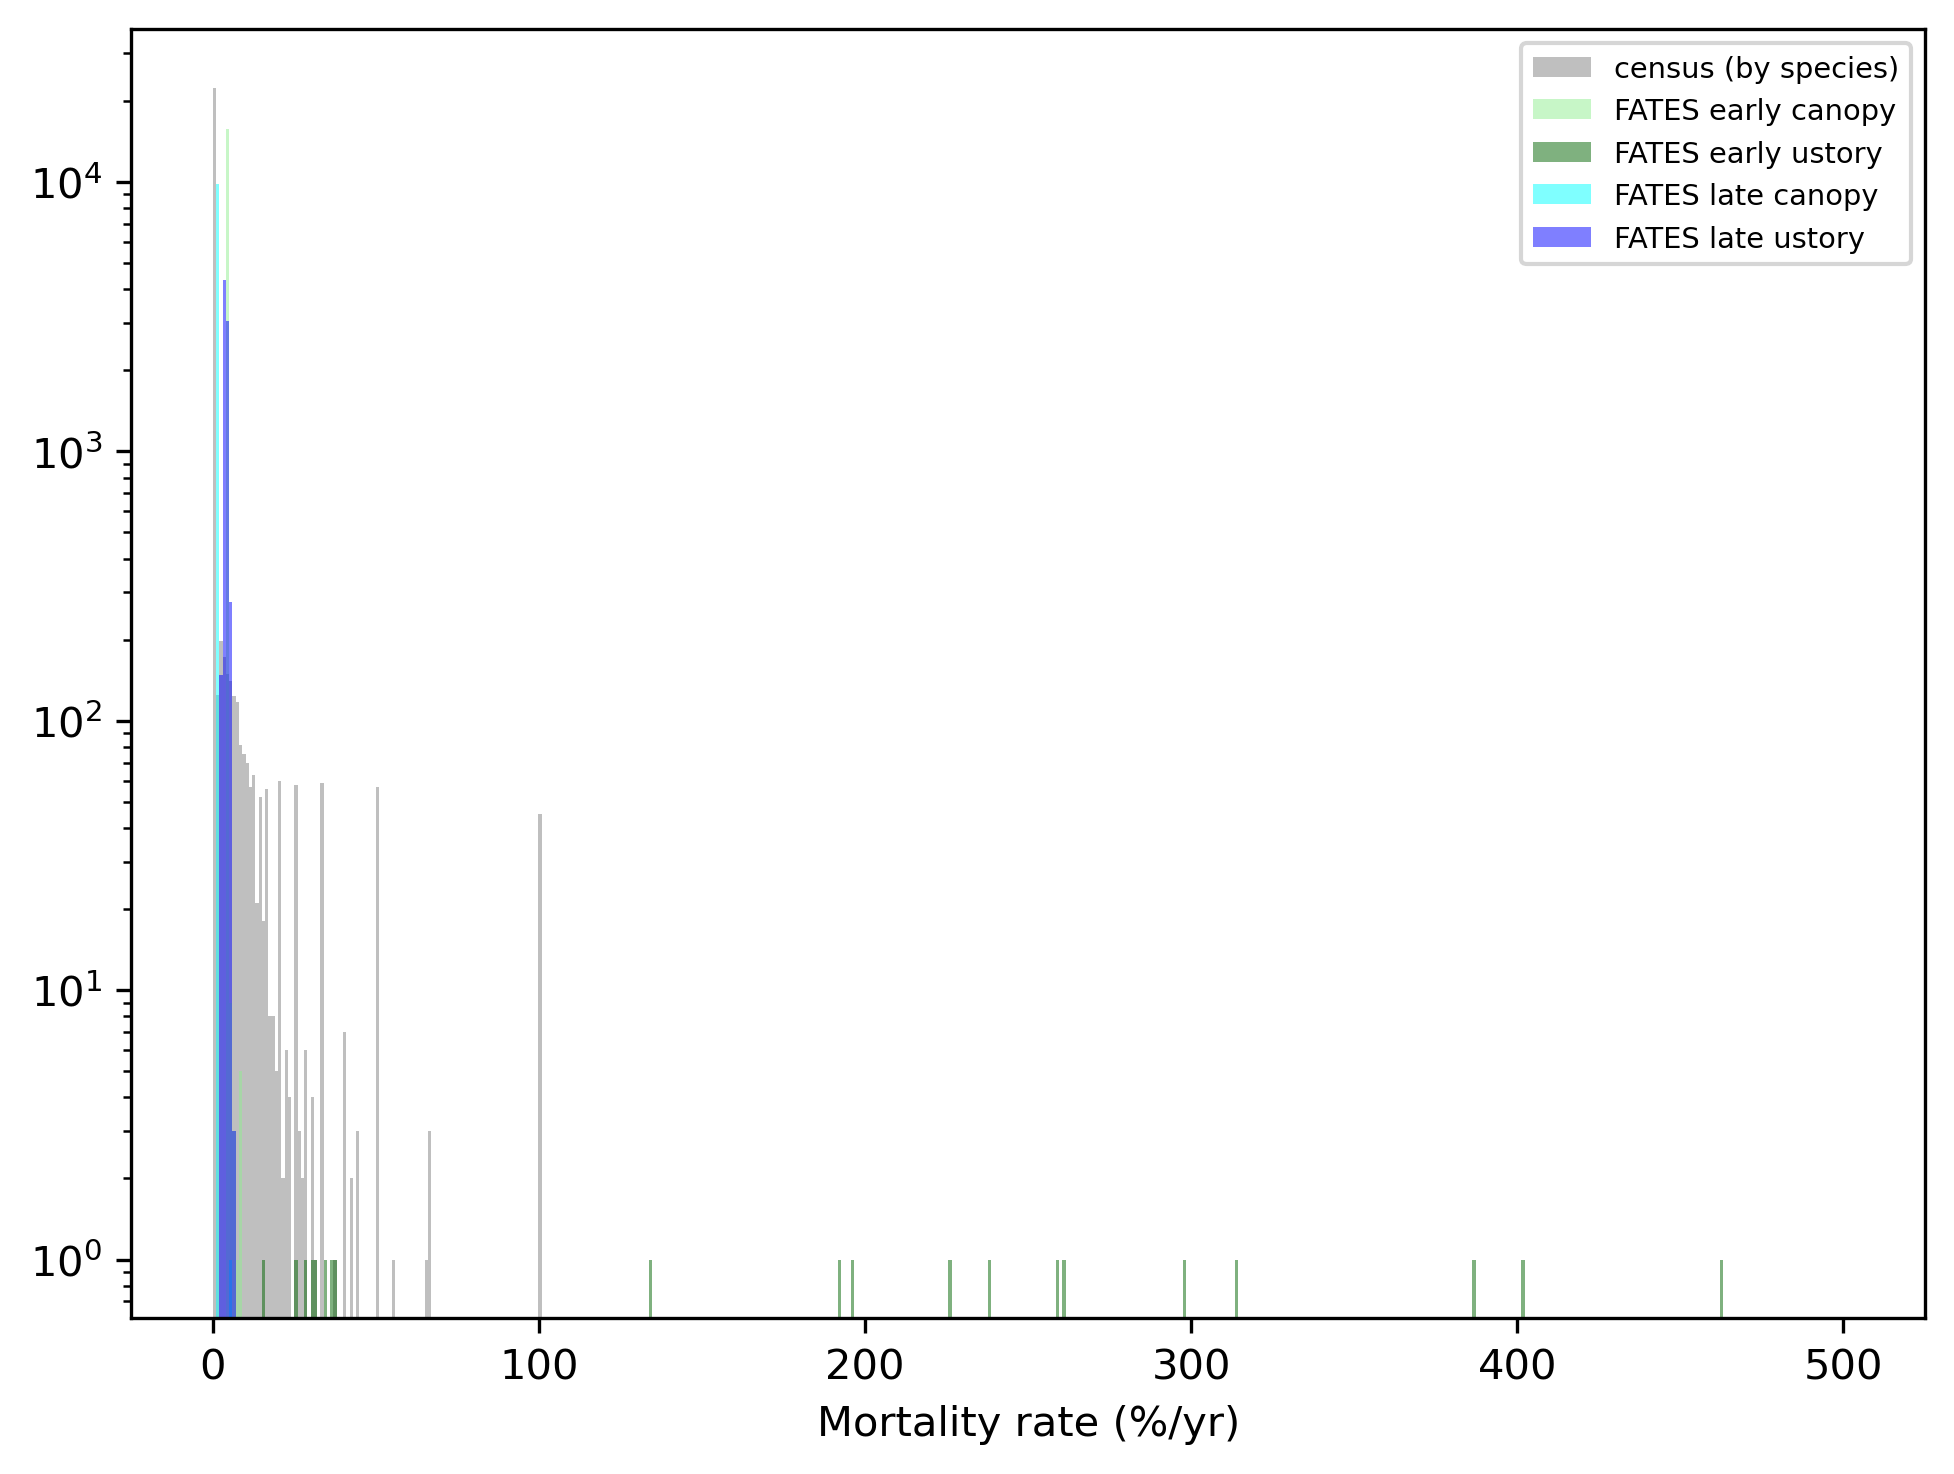

In [120]:
# Note early PFT understory cohorts can have mortality exceeding 100% per year
xmax=500
plt.hist(100*mort_by_year.flatten(), log=True, range=(0,xmax), bins=xmax+1, label="census (by species)", color="grey", alpha=0.5)
plt.hist(100.*canopy_mort_rate_early.where(early_can_filt > filt).values.flatten(), log=True, range=(0,xmax), bins=xmax+1, label="FATES early canopy", color="lightgreen", alpha=0.5)
plt.hist(100.*ustory_mort_rate_early.where(early_ust_filt > filt).values.flatten(), log=True, range=(0,xmax), bins=xmax+1, label="FATES early ustory", color="darkgreen", alpha=0.5)
plt.hist(100.*canopy_mort_rate_late.where(late_can_filt > filt).values.flatten(), log=True, range=(0,xmax), bins=xmax+1, label="FATES late canopy", color="cyan", alpha=0.5)
plt.hist(100.*ustory_mort_rate_late.where(late_ust_filt > filt).values.flatten(), log=True, range=(0,xmax), bins=xmax+1, label="FATES late ustory", color="blue", alpha=0.5)

plt.xlabel('Mortality rate (%/yr)')
plt.legend(fontsize='x-small', loc='upper right')


In [ ]:
# Maximum mortality rates:

In [122]:
np.nanmax(100*mort_by_year.flatten())

100.0

In [123]:
np.nanmax(100.*canopy_mort_rate_early.where(early_can_filt > filt).values.flatten())

8.4593725

In [124]:
np.nanmax(100.*canopy_mort_rate_late.where(late_can_filt > filt).values.flatten())

5.981353

In [125]:
np.nanmax(100.*ustory_mort_rate_early.where(early_ust_filt > filt).values.flatten())

2438.694

In [126]:
np.nanmax(100.*ustory_mort_rate_late.where(late_ust_filt > filt).values.flatten())

6.282359